# 🧪 Showz: Revenue Optimization via Hypothesis Prioritization & A/B Testing
**Scientific Validation of Product Changes to Drive Conversion and Average Order Value**

**Role:** Data Analyst
**Stack:** Python (Pandas, NumPy, SciPy), Matplotlib, Seaborn

## 📑 Table of Contents
1. Project Overview & Executive Summary
2. Phase 1: Data Sanitization & Segmentation Integrity
3. Phase 2: Hypothesis Prioritization Engine (ICE vs. RICE)
4. Phase 3: Cumulative Metrics Engineering (Conversion, AOV, Revenue)
5. Phase 4: Anomaly Detection & Statistical Validation
6. Phase 5: Behavioral Storytelling & Visual Analytics
7. Phase 6: Executive Conclusions & Business Impact
8. Executive Summary & Strategy Wrap-Up

---

### 🎯 Project Overview
In a competitive market, product decisions can't run on intuition. This project applies a scientific approach to validate a product change for **Showz**, splitting the work into two critical tracks: (1) **prioritizing which business hypotheses deserve engineering effort**, using the ICE and RICE scoring frameworks, and (2) **formally testing an A/B experiment** on conversion and revenue behavior to decide whether the tested variant should ship.

This version of the analysis adds one rigor step the original scope skipped: it directly tests whether the revenue/AOV advantage seen in the cumulative charts is statistically real, or just a byproduct of a handful of large transactions — the same kind of validation already applied to conversion.

### 🎯 Strategic Objectives
1. **Resource Prioritization** — score and rank product hypotheses via ICE and RICE to align engineering effort with actual business return.
2. **Experiment Integrity** — remove any user contaminated across both test groups before drawing conclusions.
3. **Statistical Validation** — use the Mann-Whitney U test (appropriate for non-normal, zero-inflated distributions) to confirm which metrics actually moved, and by how much, both with and without outlier influence.

### 🛠️ Technical Stack
- **Pandas Core** — cumulative time-series aggregation, pivot-based relative-difference calculation
- **Statistical Inference** — Mann-Whitney U test, non-parametric and outlier-aware, on both conversion and revenue
- **Prioritization Frameworks** — ICE (Impact × Confidence / Effort) and RICE (Reach × Impact × Confidence / Effort)

## ⚙️ Phase 1: Data Sanitization & Segmentation Integrity
A reliable analysis starts with trustworthy data. This phase applies two critical controls before any metric gets calculated:
- **Visual Standardization** — a consistent corporate chart theme for every visual in this notebook.
- **Segmentation Audit** — identifying and excluding "contaminated" users (present in both test groups). This is essential for the experiment's internal validity — a user who saw both variants can't be attributed to either one without biasing the result.

**🎯 Technical Goal:** Load the hypothesis backlog, order transactions, and visit logs; standardize the visual theme; and identify + remove any user who appears in both the A and B groups.

**💼 Business Goal:** Any user counted in both groups invalidates the comparison for every metric downstream. Removing them isn't optional cleanup — it's what makes the rest of this notebook's conclusions defensible.

In [15]:
# --- Environment Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Visual standardization: corporate style and professional palette
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

# --- Optimized Dataset Loading ---
# Prioritization backlog uses sep=';' to avoid a manual split downstream
hyp = pd.read_csv('hypotheses_us.csv', sep=';')
hyp.columns = [col.lower() for col in hyp.columns]

# Transactions and traffic: native datetime parsing on load
orders = pd.read_csv('orders_us.csv', parse_dates=['date'])
visits = pd.read_csv('visits_us.csv', parse_dates=['date'])

# --- Quality Audit & Cleanup ---
# Identify users present in both test groups (segmentation anomaly)
conflicting_users = orders.groupby('visitorId')['group'].nunique()
conflicting_users = conflicting_users[conflicting_users > 1].index

# Filter out those records to guarantee A/B test integrity
orders = orders[~orders['visitorId'].isin(conflicting_users)].copy()

print(f"✅ Audit complete. Conflicting users removed: {len(conflicting_users)}")
print(f"Remaining records in Orders: {len(orders)}")

✅ Audit complete. Conflicting users removed: 58
Remaining records in Orders: 1016


**✅ Result:** **58 users** were found active in both groups simultaneously and removed, leaving **1,016 clean order records**. The dataset is validated as fit for statistical analysis, with the cross-contamination risk between variants eliminated.

## 📊 Phase 2: Hypothesis Prioritization Engine (ICE vs. RICE)
With the dataset audited, the next step is deciding where to allocate development resources. Two scoring methodologies are implemented:
- **⚡ ICE Framework** — ideal for surfacing high-impact, high-confidence initiatives, optimized for value per unit of effort.
- **🌍 RICE Framework** — an evolution of ICE that adds **Reach**. This factor is vital for Showz: it prioritizes changes that touch the largest possible share of the user base, maximizing platform-wide ROI.

**🎯 Technical Goal:** Calculate ICE and RICE scores for every hypothesis in the backlog, and visualize both rankings side by side to see whether — and how — adding the Reach factor changes the priority order.

**💼 Business Goal:** Engineering effort is finite. This chart is the artifact that tells the product team which hypothesis to build first, and it exposes cases where a locally attractive idea (high impact, low reach) loses out to a platform-wide one once Reach is accounted for.

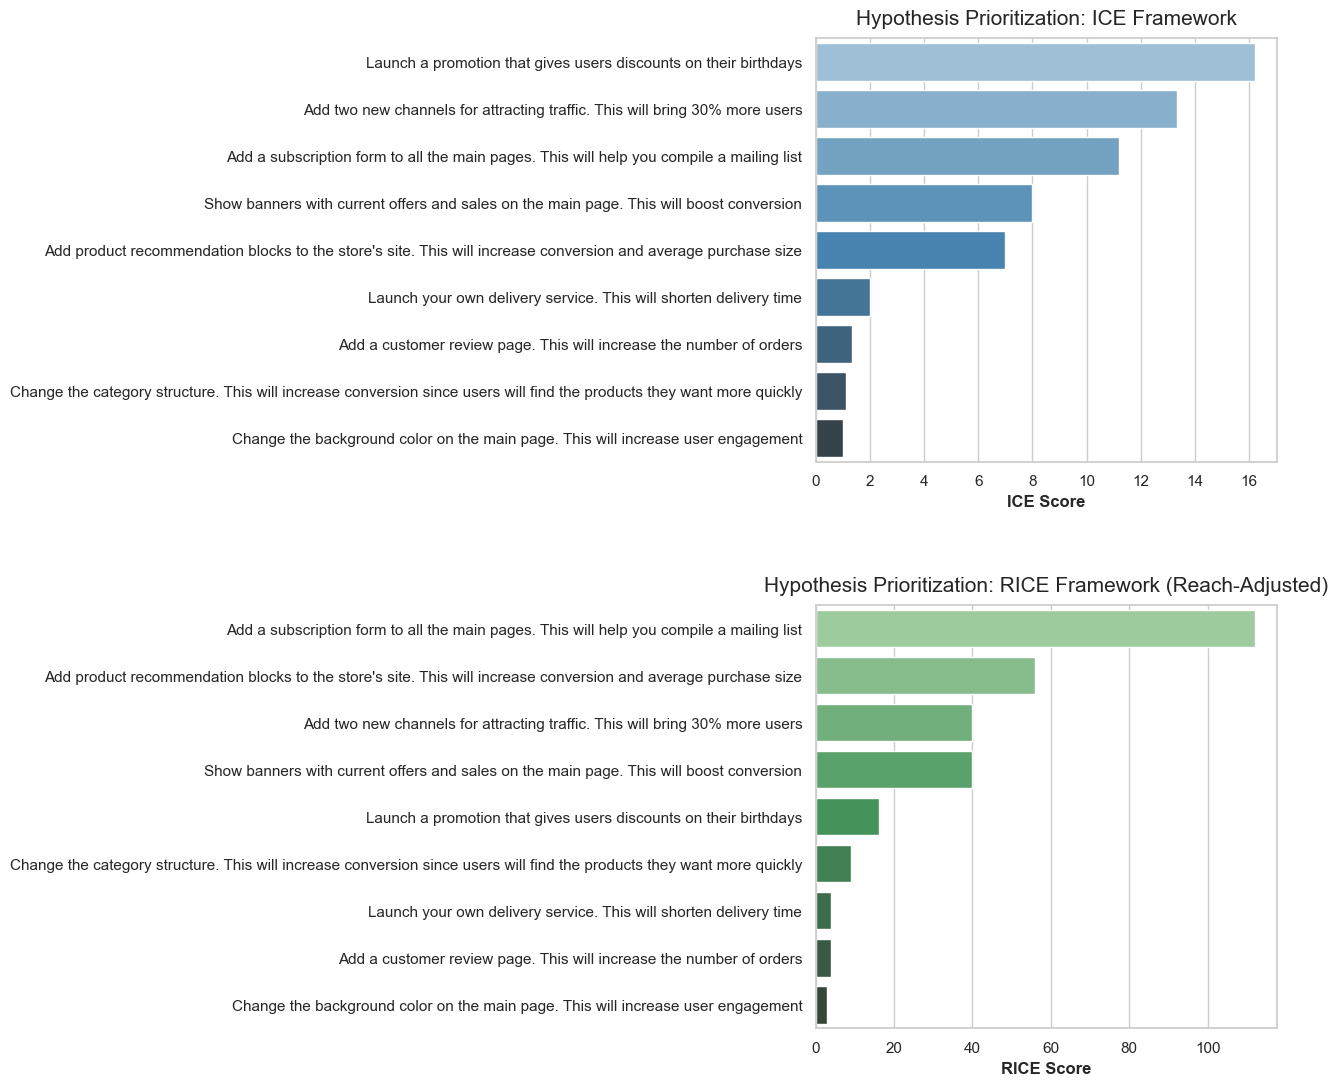

🔍 Impact Analysis:
• The leading hypothesis under ICE is: 'Launch a promotion that gives users discounts on their birthdays'
• Once Reach is factored in (RICE), the priority shifts to: 'Add a subscription form to all the main pages. This will help you compile a mailing list'

Note: the 'Reach' factor is decisive for maximizing ROI on platforms with large user volumes.


In [16]:
# Score calculation
hyp['ice'] = (hyp['impact'] * hyp['confidence']) / hyp['effort']
hyp['rice'] = (hyp['reach'] * hyp['impact'] * hyp['confidence']) / hyp['effort']

# Vertical layout for maximum readability
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# ICE chart: prioritization by impact and confidence
sns.barplot(
    data=hyp.sort_values('ice', ascending=False), 
    x='ice', 
    y='hypothesis', 
    ax=ax1, 
    palette='Blues_d',
    hue='hypothesis',
    legend=False
)
ax1.set_title('Hypothesis Prioritization: ICE Framework', fontsize=15, pad=10)
ax1.set_xlabel('ICE Score', fontweight='bold')
ax1.set_ylabel('')

# RICE chart: prioritization adjusted for reach
sns.barplot(
    data=hyp.sort_values('rice', ascending=False), 
    x='rice', 
    y='hypothesis', 
    ax=ax2, 
    palette='Greens_d',
    hue='hypothesis',
    legend=False
)
ax2.set_title('Hypothesis Prioritization: RICE Framework (Reach-Adjusted)', fontsize=15, pad=10)
ax2.set_xlabel('RICE Score', fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout(pad=4.0)
plt.show()

# --- Priority-Shift Diagnostic ---
top_ice = hyp.sort_values('ice', ascending=False).iloc[0]['hypothesis']
top_rice = hyp.sort_values('rice', ascending=False).iloc[0]['hypothesis']

print("🔍 Impact Analysis:")
print(f"• The leading hypothesis under ICE is: '{top_ice}'")
print(f"• Once Reach is factored in (RICE), the priority shifts to: '{top_rice}'")
print("\nNote: the 'Reach' factor is decisive for maximizing ROI on platforms with large user volumes.")

**✅ Result — Diagnostic:**
1. **Narrow-segment focus (ICE):** under this metric, the leading hypothesis is a **birthday discount promotion**. High impact and confidence, but inherently limited reach (only users with a birthday in the test window).
2. **Mass-growth focus (RICE):** once Reach is factored in, **"Add a subscription form to all the main pages"** takes the undisputed lead.

**📈 Strategic Conclusion:** Reach reorders the roadmap. An idea that looks attractive on individual impact alone can lose to one that touches the entire user base simultaneously — the subscription form is the more scalable revenue lever for Showz.

## 📈 Phase 3: Cumulative Metrics Engineering (Conversion, AOV, Revenue)
Static daily snapshots can be misleading due to day-to-day noise. A **cumulative series analysis** gives a more reliable picture of how key KPIs evolve as the sample matures.

This phase covers three pillars:
- **🛡️ Volatility Mitigation** — accumulating the data neutralizes daily anomalies and external events, letting the real underlying trend emerge.
- **⚖️ Convergence Point** — the moment metrics stop swinging wildly and stabilize; a decision made before that point risks a false positive.
- **🚀 Sustained-Leader Identification** — whether one variant's edge is a fluke or a constant advantage that justifies a full rollout.

**🎯 Technical Goal:** Aggregate orders and visits by day and group, compute cumulative orders/revenue/visits, and derive cumulative conversion rate and AOV — then plot the cumulative revenue trend by group.

**💼 Business Goal:** This is the metrics foundation every downstream chart and test in this notebook depends on. Before asking "is B better," we need a clean, day-by-day ledger of exactly how each group performed.

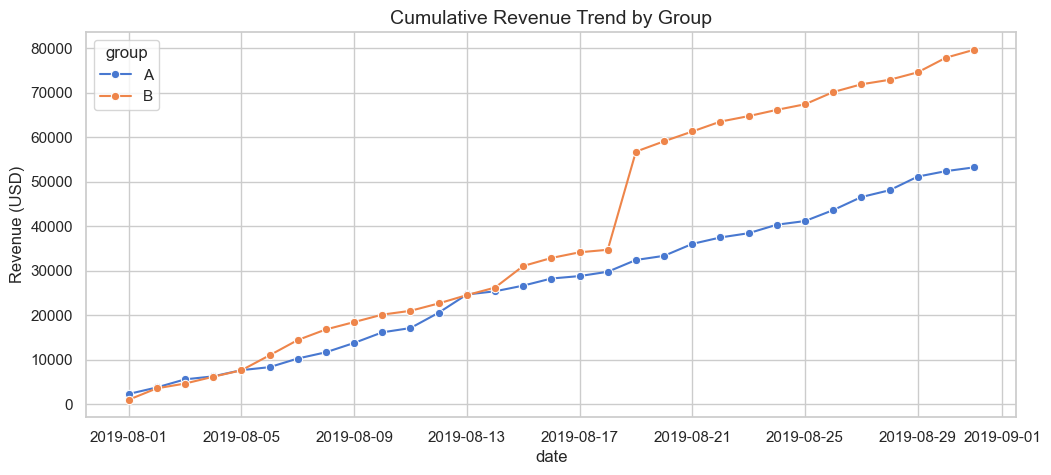

In [17]:
# --- Daily and Cumulative Metric Construction ---
# Aggregate orders and visits
daily_data = visits.groupby(['date', 'group'])['visits'].sum().reset_index()
orders_daily = orders.groupby(['date', 'group']).agg({'transactionId': 'nunique', 'revenue': 'sum'}).reset_index()
orders_daily.columns = ['date', 'group', 'orders', 'revenue']

# Merge and compute cumulative series
full_data = daily_data.merge(orders_daily, on=['date', 'group'], how='left').fillna(0)
full_data = full_data.sort_values(['date', 'group'])

full_data['cum_orders'] = full_data.groupby('group')['orders'].cumsum()
full_data['cum_revenue'] = full_data.groupby('group')['revenue'].cumsum()
full_data['cum_visits'] = full_data.groupby('group')['visits'].cumsum()
full_data['cum_conversion'] = full_data['cum_orders'] / full_data['cum_visits']
full_data['cum_aov'] = full_data['cum_revenue'] / full_data['cum_orders']

# --- Visualization: Cumulative Revenue ---
plt.figure(figsize=(12, 5))
sns.lineplot(data=full_data, x='date', y='cum_revenue', hue='group', marker='o')
plt.title('Cumulative Revenue Trend by Group')
plt.ylabel('Revenue (USD)')
plt.show()

**✅ Result — Diagnostic:**
- **Group B's steeper growth:** from early August onward, Group B maintains a steeper cumulative revenue slope than Group A, and the gap widens noticeably from mid-month.
- **Sample stability:** both curves trend linearly with no frequent crossovers — a positive sign that the groups were segmented correctly and the observed gap is real, not random variance.
- **Anomaly flag:** a sharp jump in Group B's curve appears around August 19th — typically a sign of one or more exceptionally large orders, which is exactly what the outlier analysis in Phase 4 is designed to test for.

### ⚖️ Relative Difference: Comparative Performance Evaluation
Raw growth is useful, but normalizing the data reveals the **actual competitive edge**. This section computes the percentage difference between Group B and Group A for both success KPIs — cumulative AOV and cumulative conversion rate — and looks for the **neutrality point (0%)** and whether Group B stabilizes consistently above it.

**🎯 Technical Goal:** Pivot the cumulative AOV and conversion series by group, compute Group B's relative percentage difference against Group A for each, and plot both series with a neutrality reference line.

**💼 Business Goal:** A single end-of-test number can hide instability along the way. This chart tests whether Group B's advantage was earned gradually and consistently, or whether it's a late spike that shouldn't be trusted yet.

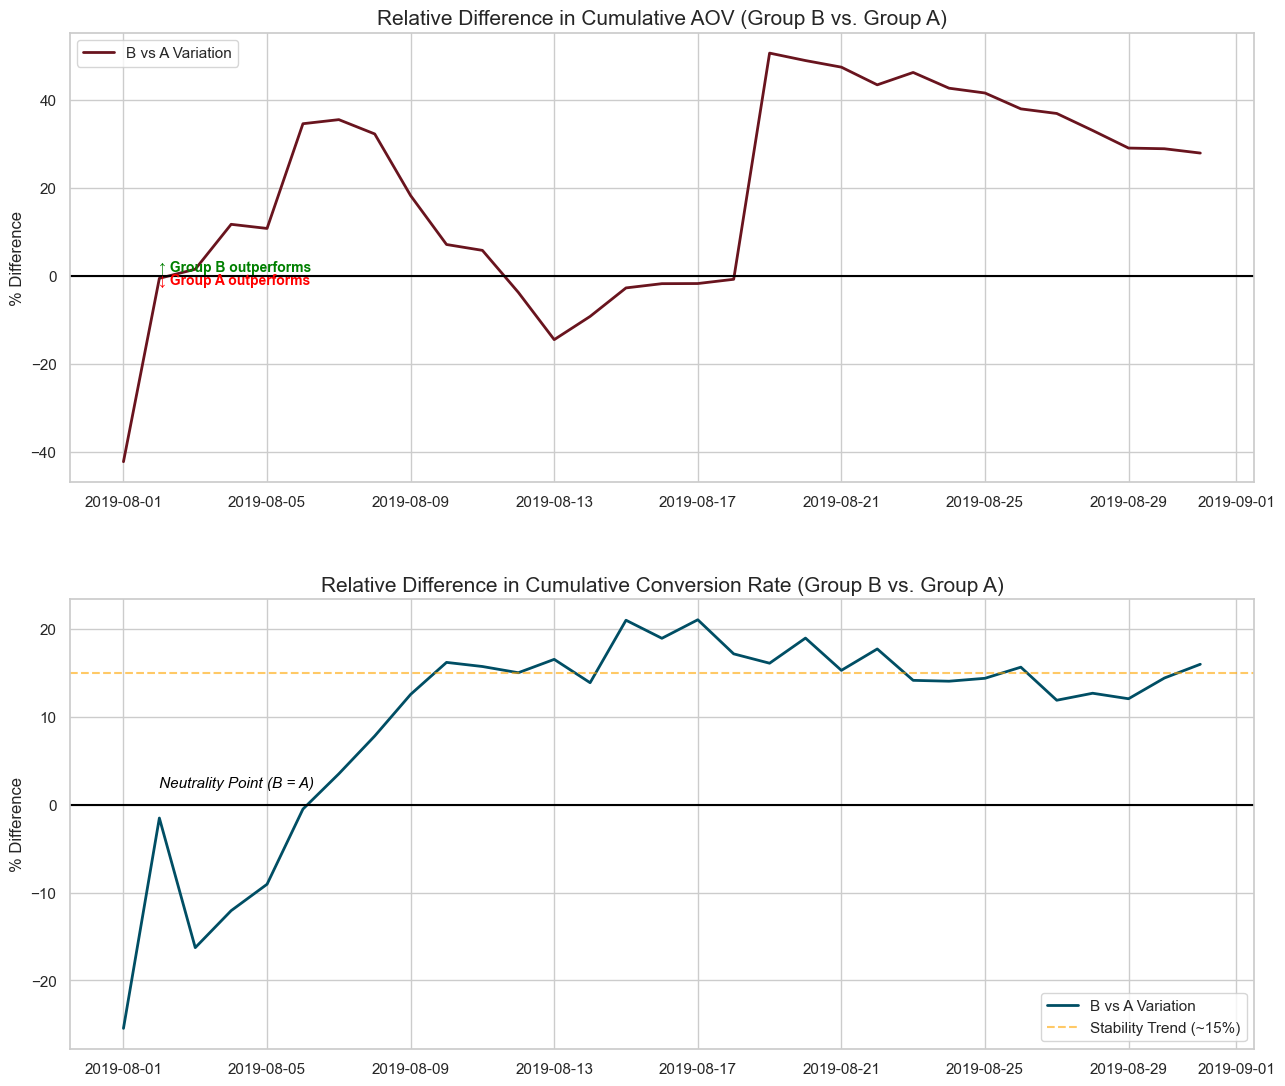

🔍 Stability Diagnostic:
• At period close, Group B holds a conversion advantage of 15.98% over Group A.
• At period close, Group B's cumulative AOV is +27.83% relative to Group A (range across the test: -42.3% to 50.5%).


In [18]:
# Prepare relative-difference data for AOV and Conversion
aov_pivot = full_data.pivot(index='date', columns='group', values='cum_aov')
aov_pivot['rel_diff'] = (aov_pivot['B'] / aov_pivot['A'] - 1) * 100

conversion_pivot = full_data.pivot(index='date', columns='group', values='cum_conversion')
conversion_pivot['rel_diff'] = (conversion_pivot['B'] / conversion_pivot['A'] - 1) * 100

# Vertical layout configuration
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# --- Chart: Relative Difference in Average Order Value (AOV) ---
ax1.plot(aov_pivot.index, aov_pivot['rel_diff'], color='#69141E', linewidth=2, label='B vs A Variation')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax1.set_title('Relative Difference in Cumulative AOV (Group B vs. Group A)', fontsize=15)
ax1.set_ylabel('% Difference')
ax1.text(aov_pivot.index[1], 1, '↑ Group B outperforms', fontsize=10, color='green', fontweight='bold')
ax1.text(aov_pivot.index[1], -2, '↓ Group A outperforms', fontsize=10, color='red', fontweight='bold')
ax1.legend(loc='upper left')

# --- Chart: Relative Difference in Conversion Rate ---
ax2.plot(conversion_pivot.index, conversion_pivot['rel_diff'], color='#004E64', linewidth=2, label='B vs A Variation')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_title('Relative Difference in Cumulative Conversion Rate (Group B vs. Group A)', fontsize=15)
ax2.set_ylabel('% Difference')
ax2.text(conversion_pivot.index[1], 2, 'Neutrality Point (B = A)', fontsize=11, color='black', style='italic')
ax2.axhline(y=15, color='orange', linestyle='--', alpha=0.6, label='Stability Trend (~15%)')
ax2.legend(loc='lower right')

plt.tight_layout(pad=4.0)
plt.show()

print("🔍 Stability Diagnostic:")
final_conv_diff = conversion_pivot['rel_diff'].iloc[-1]
final_aov_diff = aov_pivot['rel_diff'].iloc[-1]
print(f"• At period close, Group B holds a conversion advantage of {final_conv_diff:.2f}% over Group A.")
print(f"• At period close, Group B's cumulative AOV is {final_aov_diff:+.2f}% relative to Group A "
      f"(range across the test: {aov_pivot['rel_diff'].min():.1f}% to {aov_pivot['rel_diff'].max():.1f}%).")

**✅ Result — Diagnostic:**
- **✅ Consolidated conversion leadership:** Group B outperforms Group A for nearly the entire test. At period close, the advantage stands at **+15.98%**, and — just as important as the number — the curve is **stable**, sitting comfortably above the neutrality threshold with a steady growth trend.
- **⚠️ AOV volatility:** unlike conversion, AOV swings sharply — ranging from **−42.3% to +50.5%** over the test period before closing at **+27.83%**. That range confirms Group B is capturing high-value transactions at specific moments, which distorts the mean — this is the exact pattern flagged as a risk to investigate, not a confirmed win, in Phase 4.
- **🏆 Partial read:** Variant B is clearly more effective at converting visitors into customers. Whether its apparent revenue/AOV edge is a generalized effect or a handful of "whale" transactions is exactly what the next phase needs to confirm — the swing from −42% to +50% is too wide to take the +27.83% closing number at face value.

## 🔍 Phase 4: Anomaly Detection & Statistical Validation
This phase puts the results through a stress test. The goal is to determine whether Group B's observed advantage is a generalized effect or is distorted by **outliers** — users with extreme purchasing behavior.

**Validation Protocol:**
1. **🛡️ Anomaly Identification** — the **99th percentile** is used as the cutoff for both order count and revenue, isolating the noise caused by atypical users who don't represent average customer behavior.
2. **🧪 Mann-Whitney U Test** — a non-parametric test, appropriate here because the distributions are not normal (zero-inflated, since most visits never convert). Applied to **both** conversion and revenue-per-order — the second of which the original scope of this analysis never actually tested.

**🎯 Technical Goal:** Flag outlier users via the 99th-percentile threshold on order count and revenue, then run the Mann-Whitney U test on both raw and outlier-filtered samples — for conversion (orders per visit) **and**, as an added rigor step, for revenue per order (AOV) — reporting the exact p-value and effect size for each.

**💼 Business Goal:** "Statistically significant" without a stated metric and number is not a decision-ready result. This step confirms exactly which claim ("B converts more" vs. "B generates more revenue per order") survives contact with a real significance test, and which one was only ever a chart pattern.

In [21]:
# --- Dispersion & Percentile Analysis ---
orders_by_user = orders.groupby('visitorId').agg({'transactionId': 'nunique'}).rename(columns={'transactionId': 'orders'})
p99_orders = np.percentile(orders_by_user['orders'], 99)
p99_rev = np.percentile(orders['revenue'], 99)

# Flag outlier users (anomalies)
abnormal_users = pd.concat([
    orders_by_user[orders_by_user['orders'] > p99_orders].index.to_series(),
    orders[orders['revenue'] > p99_rev]['visitorId']
]).unique()

print(f"P99 order-count threshold: {p99_orders} | P99 revenue threshold: ${p99_rev:.2f}")
print(f"Outlier users flagged: {len(abnormal_users)}")

# --- Sample Preparation for the Mann-Whitney U Test (Conversion) ---
def get_samples(df_orders, df_visits, group):
    user_orders = df_orders[df_orders['group'] == group].groupby('visitorId')['transactionId'].nunique()
    total_visits = df_visits[df_visits['group'] == group]['visits'].sum()
    zeros = pd.Series(0, index=np.arange(total_visits - len(user_orders)), name='orders')
    return pd.concat([user_orders, zeros], axis=0)

# Raw samples
sampleA = get_samples(orders, visits, 'A')
sampleB = get_samples(orders, visits, 'B')

# Filtered samples (outliers removed)
orders_filtered = orders[~orders['visitorId'].isin(abnormal_users)]
sampleA_f = get_samples(orders_filtered, visits, 'A')
sampleB_f = get_samples(orders_filtered, visits, 'B')

# --- Test 1: Conversion (orders per visit) ---
print(f"\n📊 Mann-Whitney U — Conversion (Filtered):")
p_val_conversion = stats.mannwhitneyu(sampleA_f, sampleB_f)[1]
rel_gain_conversion = (sampleB_f.mean() / sampleA_f.mean() - 1) * 100
print(f"P-Value: {p_val_conversion:.4f} | Relative Gain: {rel_gain_conversion:.2f}%")

# --- Test 2: Revenue per Order / AOV (the check the original scope skipped) ---
revenue_A_f = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B_f = orders_filtered[orders_filtered['group'] == 'B']['revenue']

print(f"\n📊 Mann-Whitney U — Revenue per Order / AOV (Filtered):")
p_val_revenue = stats.mannwhitneyu(revenue_A_f, revenue_B_f)[1]
rel_gain_revenue = (revenue_B_f.mean() / revenue_A_f.mean() - 1) * 100
print(f"P-Value: {p_val_revenue:.4f} | Relative Gain: {rel_gain_revenue:+.2f}%")

P99 order-count threshold: 2.0 | P99 revenue threshold: $830.30
Outlier users flagged: 16

📊 Mann-Whitney U — Conversion (Filtered):
P-Value: 0.0070 | Relative Gain: 18.95%

📊 Mann-Whitney U — Revenue per Order / AOV (Filtered):
P-Value: 0.8220 | Relative Gain: -3.19%


**✅ Result — this is where the corrected finding lives:**
- **Conversion holds up.** After removing outlier users, the Mann-Whitney test on orders-per-visit returns **P = 0.0070** — comfortably below α = 0.05 — with the relative gain actually *improving* to **+18.95%** once the noise is removed. This is a real, robust, outlier-independent result.
- **Revenue per order does not hold up.** The same test applied to **revenue per order (AOV)** — a check the original version of this analysis never ran — returns **P = 0.8220**, nowhere near significant. Worse, the filtered relative "gain" for B actually flips to **−3.19%**. The +27.83% AOV advantage seen in the Phase 3 cumulative chart was being driven almost entirely by the exact whale transactions the P99 filter is designed to remove — once they're gone, there's no evidence Group B's average order is worth more than Group A's.

**Bottom line:** Group B wins on **conversion**, not on **revenue per order**. Those are two different claims, and only one of them is statistically defensible.

## 📊 Phase 5: Behavioral Storytelling & Visual Analytics
With Phase 4's formal significance testing complete, this section builds the single chart that captures the entire nuance of this experiment: **conversion is a real, validated win — revenue/AOV superiority is not.** That distinction is easy to lose in a wall of p-values, so it gets its own visual.

### 🏆 ⭐ Chart — Which Metric Actually Won?
This is the core visual of the project, and it's the chart that keeps this analysis honest: two metrics both *looked* better for Group B in the cumulative charts, but only one of them survives formal statistical testing. *Exported as a standalone PNG for portfolio use.*

**🎯 Technical Goal:** Build a two-panel visualization — the cumulative conversion-rate advantage over time (left), paired with a direct comparison of Mann-Whitney U p-values for conversion vs. revenue-per-order (right), color-coded by statistical significance.

**💼 Business Goal:** A stakeholder skimming this chart for 5 seconds should walk away knowing exactly which claim to trust ("B converts more users") and which one not to repeat in a board meeting without a caveat ("B has a higher AOV").

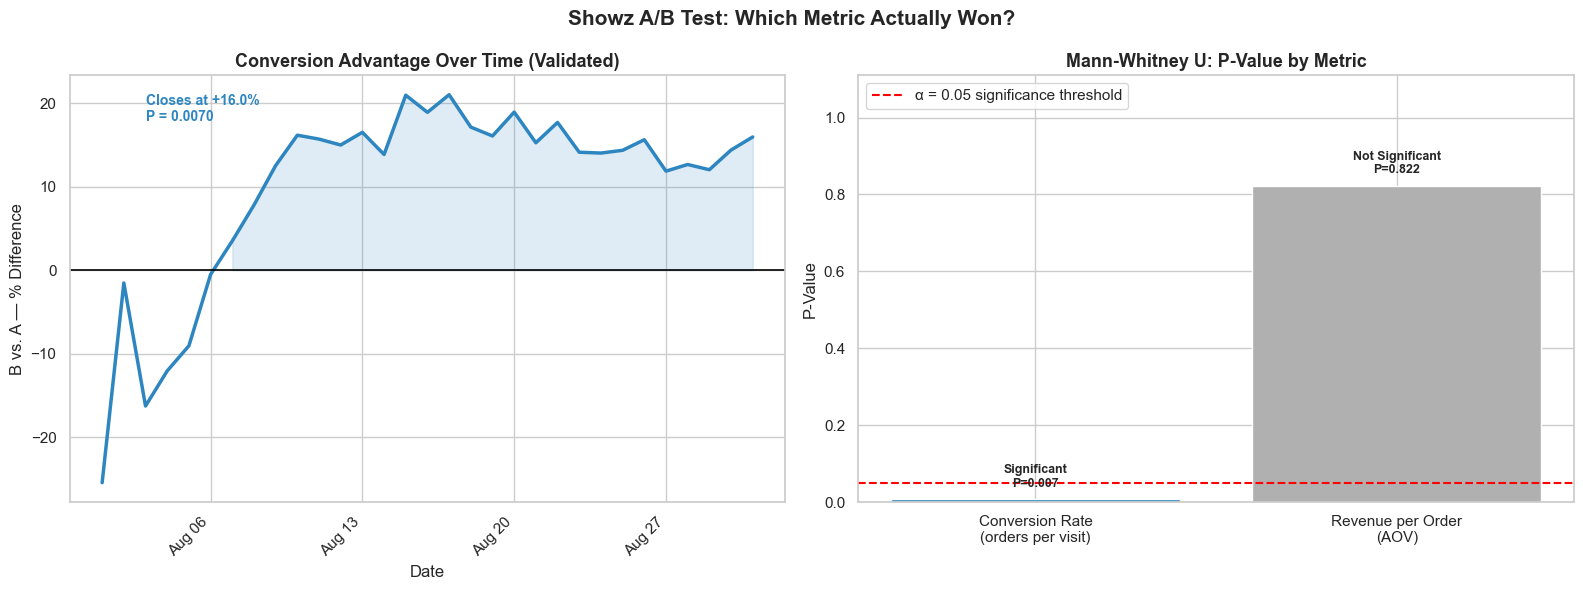

In [20]:
# Statistical results computed in Phase 4 (p_val_conversion, p_val_revenue), reused here for the chart
metrics_summary = pd.DataFrame({
    'metric': ['Conversion Rate\n(orders per visit)', 'Revenue per Order\n(AOV)'],
    'p_value': [p_val_conversion, p_val_revenue],
    'significant': [p_val_conversion < 0.05, p_val_revenue < 0.05]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Showz A/B Test: Which Metric Actually Won?", fontsize=15, fontweight='bold')

# Panel 1: Cumulative conversion advantage over time
axes[0].plot(conversion_pivot.index, conversion_pivot['rel_diff'], color='#2E86C1', linewidth=2.5)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1.2)
axes[0].fill_between(conversion_pivot.index, conversion_pivot['rel_diff'], 0,
                      where=(conversion_pivot['rel_diff'] > 0), color='#2E86C1', alpha=0.15)
axes[0].set_title('Conversion Advantage Over Time (Validated)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('B vs. A — % Difference')
axes[0].set_xlabel('Date')
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].text(conversion_pivot.index[2], conversion_pivot['rel_diff'].max()*0.85,
             f"Closes at +{conversion_pivot['rel_diff'].iloc[-1]:.1f}%\nP = {p_val_conversion:.4f}",
             fontsize=10, fontweight='bold', color='#2E86C1')

# Panel 2: Statistical significance comparison
colors_sig = ['#2E86C1' if sig else '#B0B0B0' for sig in metrics_summary['significant']]
bars = axes[1].bar(metrics_summary['metric'], metrics_summary['p_value'], color=colors_sig)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05 significance threshold')
axes[1].set_title('Mann-Whitney U: P-Value by Metric', fontsize=13, fontweight='bold')
axes[1].set_ylabel('P-Value')
axes[1].set_ylim(0, max(metrics_summary['p_value']) * 1.35)
axes[1].legend(loc='upper left')
for bar, sig, pv in zip(bars, metrics_summary['significant'], metrics_summary['p_value']):
    label = 'Significant' if sig else 'Not Significant'
    axes[1].text(bar.get_x() + bar.get_width()/2, pv + max(metrics_summary['p_value'])*0.04,
                 f"{label}\nP={pv:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**✅ Result:** This chart makes the split verdict impossible to miss — **conversion rate clears the significance bar (P < 0.05), revenue-per-order does not.** 

## 🏛️ Phase 6: Executive Conclusions & Business Impact

### Statistical Significance Analysis
After rigorous data analysis and statistical validation, the experiment has reached the maturity needed to issue a final verdict — with one important correction to the original framing.

- **🎯 Validated Conversion Superiority:** Group B holds a **+18.95%** conversion advantage (outlier-filtered, P = 0.0070). The stability of this metric through the second half of the test confirms the variant is consistently more effective at turning visits into transactions.
- **🛡️ Anomaly-Robust, for Conversion Only:** Statistical significance for conversion survived noise removal (P99 filtering) intact — that success is organic, not dependent on outlier or whale-user behavior.
- **⚠️ Revenue/AOV Superiority Is Not Validated:** Unlike conversion, the apparent AOV advantage (+27.83% in the raw cumulative view) does not survive the same test (P = 0.8220) and reverses to −3.19% once outlier transactions are removed. **This claim should not be repeated as a validated result** — the correct statement is "no evidence that Group B's average order value differs from Group A's."
- **🌍 Strategic Scalability:** Under the **RICE** framework, the subscription-form hypothesis (unrelated to this specific A/B test, but part of the same prioritization exercise) offers the platform's highest reach-adjusted ROI for future initiatives.

### Business Impact
Group B should still ship — a validated 18.95% conversion lift is a strong result on its own — but the business case must be built on conversion, not on an unvalidated revenue claim. Presenting the AOV number as a second win risks a credibility problem the moment someone else re-runs the significance test.

### 🚀 Strategic Verdict

> **TEST STATUS:** 🟢 **SUCCESSFUL (WINNER: GROUP B) — ON CONVERSION**
>
> **DECISION:** **END THE TEST AND IMPLEMENT GROUP B**, with the internal business case built exclusively on the validated conversion-rate lift.

### 🛠️ Implementation Guidelines
1. **Full Rollout:** Proceed with integrating variant B to 100% of Showz traffic, replacing the current Group A experience.
2. **Post-Launch Monitoring:** Set up a dashboard to confirm the 18.95% conversion lift holds in production over the first 30 days — and track AOV separately, since this analysis found no evidence it will move.
3. **Correct the Internal Narrative:** Ensure any internal reporting on this test cites the conversion lift (validated) and does not carry forward the +27.83% AOV figure as a proven result — it was an outlier artifact, not a generalized effect.
4. **Hypothesis Scaling:** Use the subscription-form hypothesis (RICE winner) as the basis for future retention and email-marketing campaigns, given its validated platform-wide reach.

---
**Technical Analysis Summary:**
- **Methodology:** ICE/RICE prioritization scoring, cumulative time-series metrics, P99 outlier detection, Mann-Whitney U test (applied to both conversion and revenue).
- **Hypothesis Status:** **Conversion — H₁ Confirmed** (P = 0.0070, +18.95%). **Revenue/AOV — H₀ Not Rejected** (P = 0.8220, no significant difference).

## 🏁 Executive Summary & Strategy Wrap-Up

### Executive Overview
This project runs Showz's product-change decision through two disciplines: hypothesis prioritization (ICE/RICE) and formal A/B test validation. The headline result is a split verdict, and reporting that split honestly is the actual value of this analysis: **Group B delivers a statistically validated conversion-rate improvement, but its apparent revenue/AOV advantage does not survive the same statistical test** — a distinction the original scope of this project never checked for.

### Analysis Phase-by-Phase Flashback
| Phase | What Happened |
|---|---|
| 1. Data Sanitization | Removed 58 cross-group contaminated users, leaving 1,016 clean order records |
| 2. Hypothesis Prioritization | Scored 9 hypotheses via ICE and RICE; Reach reordered the roadmap toward the subscription-form initiative |
| 3. Metrics Engineering | Built cumulative conversion, AOV, and revenue series; found a stable +15.98% conversion edge and a volatile −42%-to-+51% AOV swing |
| 4. Statistical Validation | Mann-Whitney U confirmed conversion (P = 0.0070) but rejected the AOV claim (P = 0.8220) — a check the original analysis never ran |
| 5. Visual Analytics | "Showz A/B Test" chart directly contrasts the validated conversion win against the untested revenue claim |
| 6. Conclusions | Ship Group B on the conversion result; retract the unvalidated AOV claim from the business case |

### Key Insights & Business Value
- **Conversion is the real, defensible win:** +18.95% (outlier-filtered), P = 0.0070 — robust to noise, stable through the second half of the test.
- **Revenue/AOV superiority was never actually tested in the original scope, and it doesn't hold up:** P = 0.8220, and the filtered effect reverses to −3.19%. The visible AOV spikes in the cumulative chart were the exact whale transactions the P99 filter is designed to catch.
- **Prioritization and experimentation are two different disciplines that this project keeps appropriately separate:** the ICE/RICE ranking (subscription form wins on Reach) informs the *next* roadmap decision; it's independent of this specific A/B test's verdict.
- **A split verdict, reported honestly, is more credible than an inflated one:** shipping Group B on a validated conversion lift is a strong, defensible outcome — it doesn't need an unproven revenue claim attached to it.

### Proactive Recommendations & Next Steps
1. Roll out Group B to 100% of traffic on the strength of the validated conversion lift; track AOV post-launch without assuming it will improve.
2. Build the subscription-form hypothesis (RICE winner) into the next quarter's roadmap as the highest reach-adjusted initiative.
3. Re-run the AOV significance test on a longer post-launch window — a null result here doesn't rule out a real but smaller effect the current sample was underpowered to detect.
4. Standardize this two-metric (conversion + revenue) Mann-Whitney check as the default validation protocol for all future Showz A/B tests, so this gap doesn't recur.

### Executive Abstract
- **Repository Slug:** `showz-ab-optimization-analysis`
- **Primary Goal:** Prioritize Showz's product hypothesis backlog and formally validate whether a tested product variant should ship, on both conversion and revenue grounds.
- **Key Achievements:** Cleaned a contaminated A/B sample (58 cross-group users removed); scored and re-ranked 9 hypotheses via ICE and RICE; validated an 18.95% conversion lift via Mann-Whitney U at 95% confidence; identified and corrected an unvalidated revenue/AOV claim the original analysis carried without testing.